# Classic Super-Resolution Techniques

Profiles five families of classical super-resolution techniques over the
whole HR/LR dataset:

1. Bilinear, Bicubic, Area and Lanczos interpolation
2. Iterative Back-Projection (IBP)
3. Non-Local Means Super-Resolution
4. Edge-Guided Interpolation (EGI)
5. Frequency Domain Extrapolation

The benchmark itself lives in `classic_benchmark.py`; this notebook only runs
it and draws the figures.

In [1]:
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../")))

from srlib.constants import CLASSIC_RESULTS_DIR
from srlib.classic.benchmark import (
    ClassicSuperResolutionBenchmark,
)
from srlib.classic.visualization import (
    plot_and_save_ssim_similarity_maps,
    plot_and_save_super_resolution_example,
    plot_edge_metrics_grid,
    plot_error_metrics_grid,
    plot_frequency_distribution_metrics_grid,
    plot_psnr_ssim_panels,
    plot_speed_quality_tradeoff_3d,
    plot_time_memory_panels,
    show_algorithm_ranking,
)

CLASSIC_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

## Run the benchmark

Runs the eight algorithms over every LR/HR pair, recording time, peak memory
and nine quality metrics each. The results object carries the algorithm order
and the colour map, so every figure below stays consistent.

In [2]:
benchmark = ClassicSuperResolutionBenchmark()
results = benchmark.run()

metric_summary = results.metric_summary
algorithms = results.algorithms
colors = results.colors

print(f"Image pairs profiled: {results.pair_count}")


 Classic SR benchmark | 8 algorithms x 360 pairs
  algorithms bilinear, bicubic, area, lanczos, ibp, nlm, egi, freq


  pairs: 100%|██████████| 360/360 [10:55<00:00,  1.82s/pair]

  done in 10m 55.1s



Image pairs profiled: 360


## Cost and quality summaries

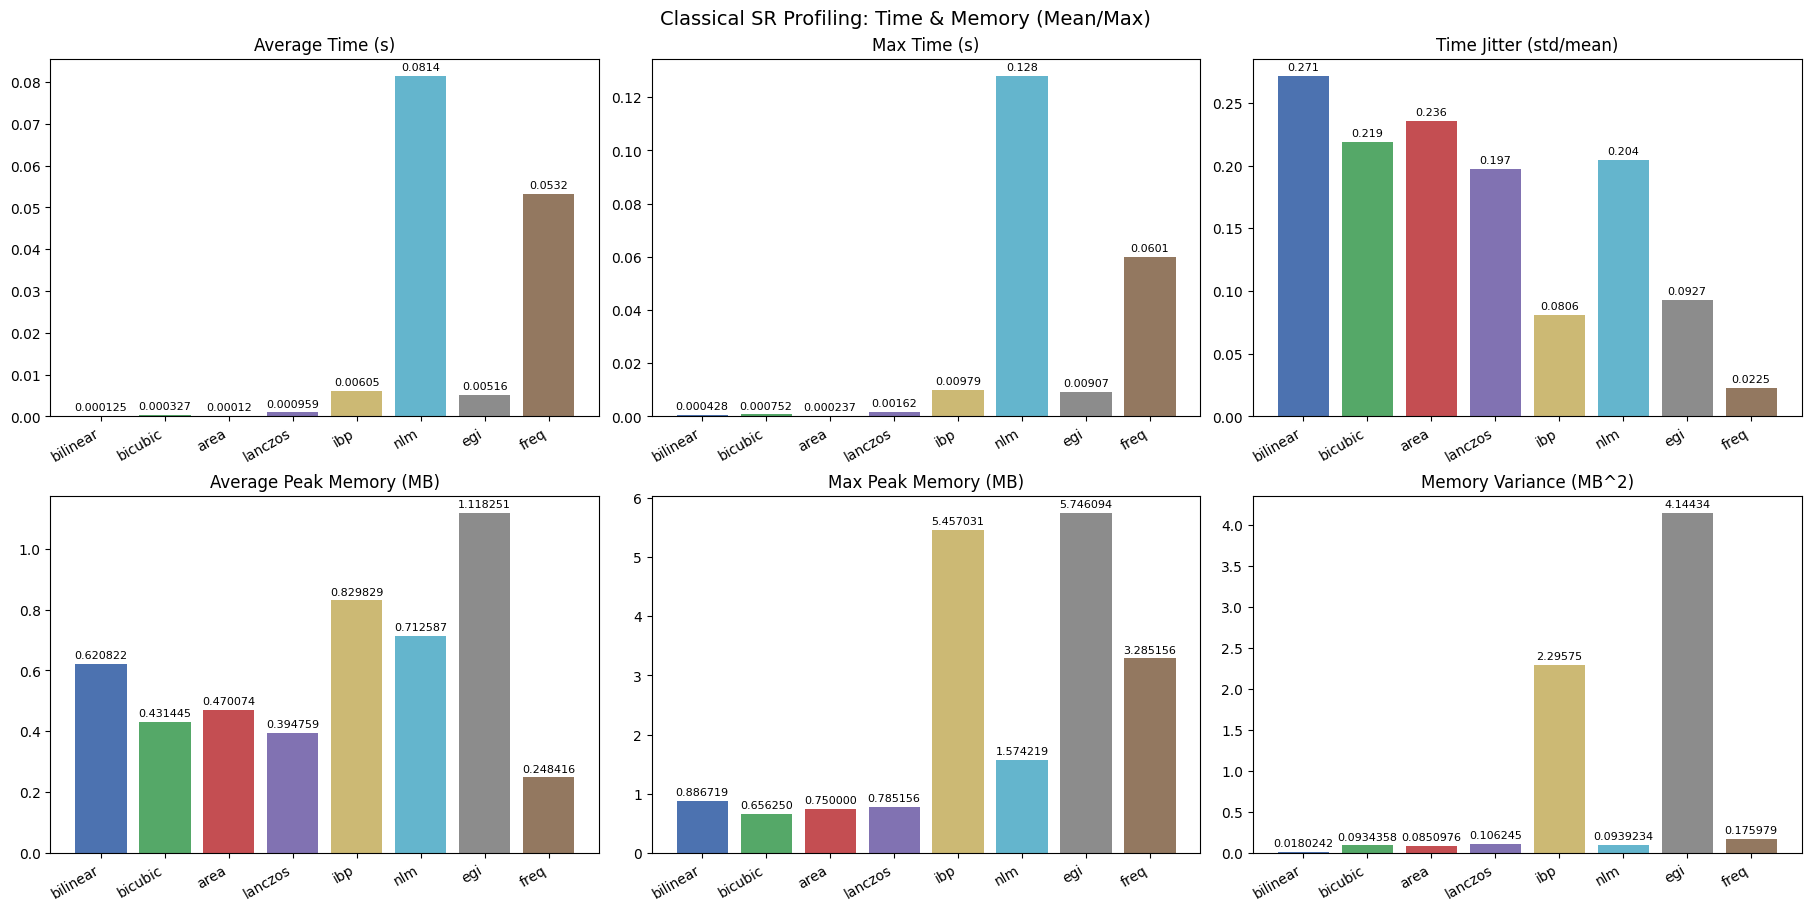

In [3]:
plot_time_memory_panels(
    metric_summary=metric_summary,
    algorithms_order=algorithms,
    colors_map=colors,
    main_title='Classical SR Profiling: Time & Memory (Mean/Max)',
    outfile=CLASSIC_RESULTS_DIR / 'time_memory_summary.png',
    figsize=(18, 9)
)

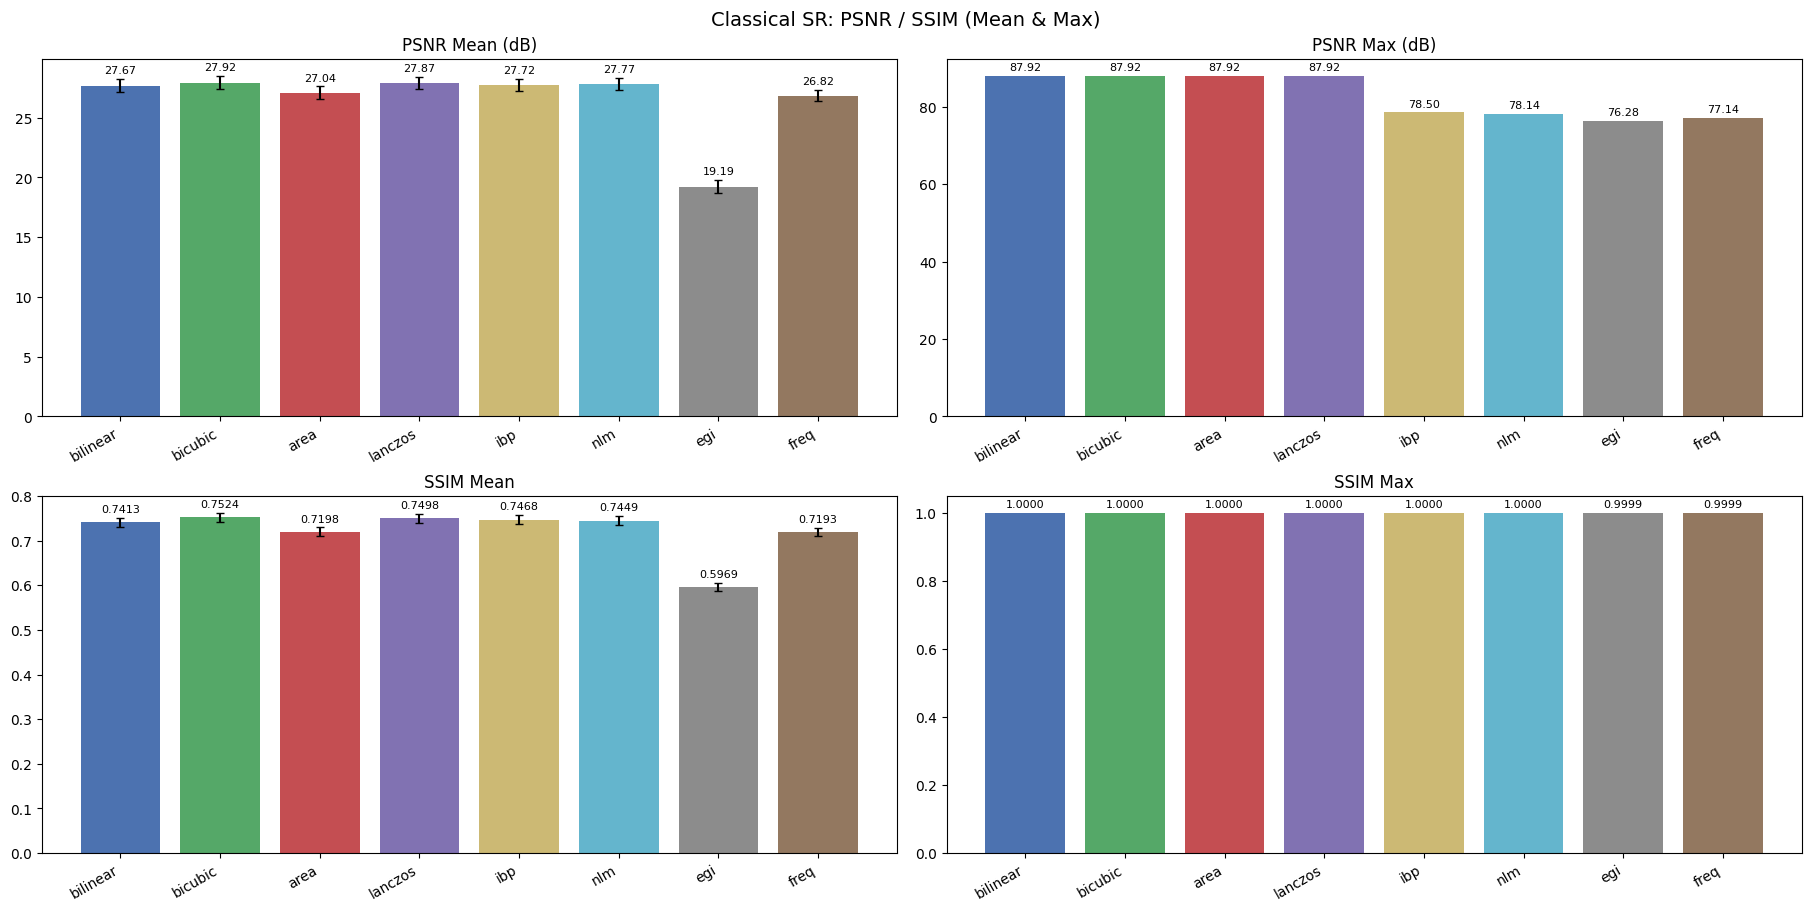

In [4]:
plot_psnr_ssim_panels(
    metric_summary=metric_summary,
    algorithms_order=algorithms,
    colors_map=colors,
    main_title='Classical SR: PSNR / SSIM (Mean & Max)',
    outfile=CLASSIC_RESULTS_DIR / 'psnr_ssim_summary.png',
    figsize=(18, 9)
)

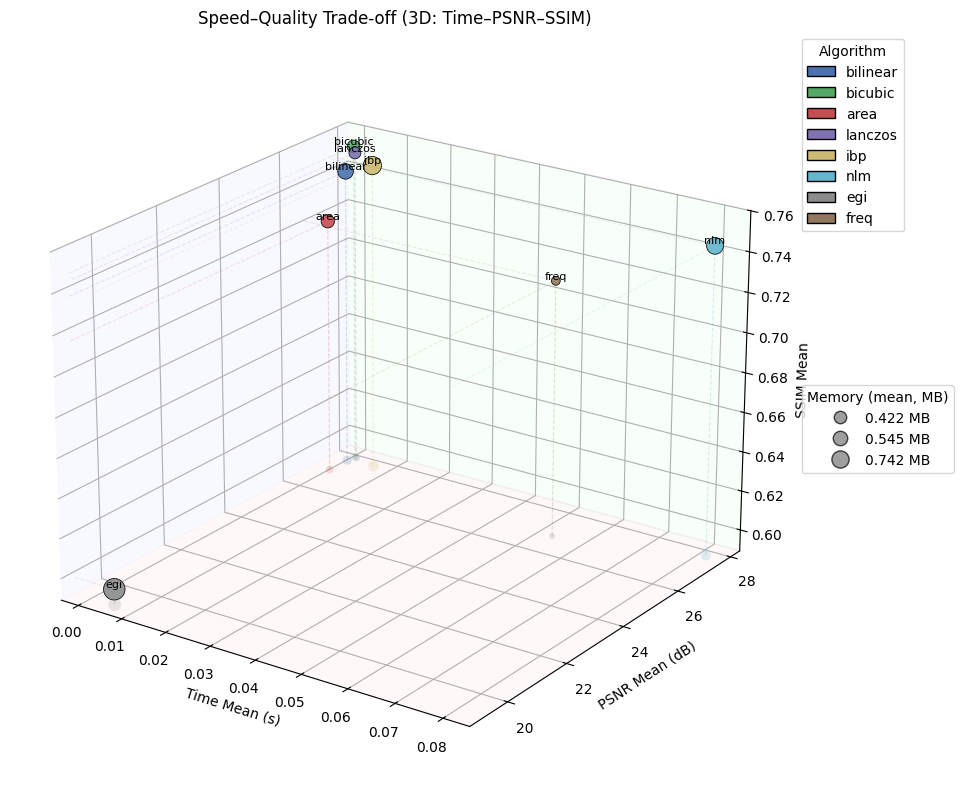

In [5]:
plot_speed_quality_tradeoff_3d(
    metric_summary=metric_summary,
    algorithms=algorithms,
    colors=colors,
    results_dir=CLASSIC_RESULTS_DIR,
    save=True,
    figsize=(10, 8),
    view=(22, -55),
)

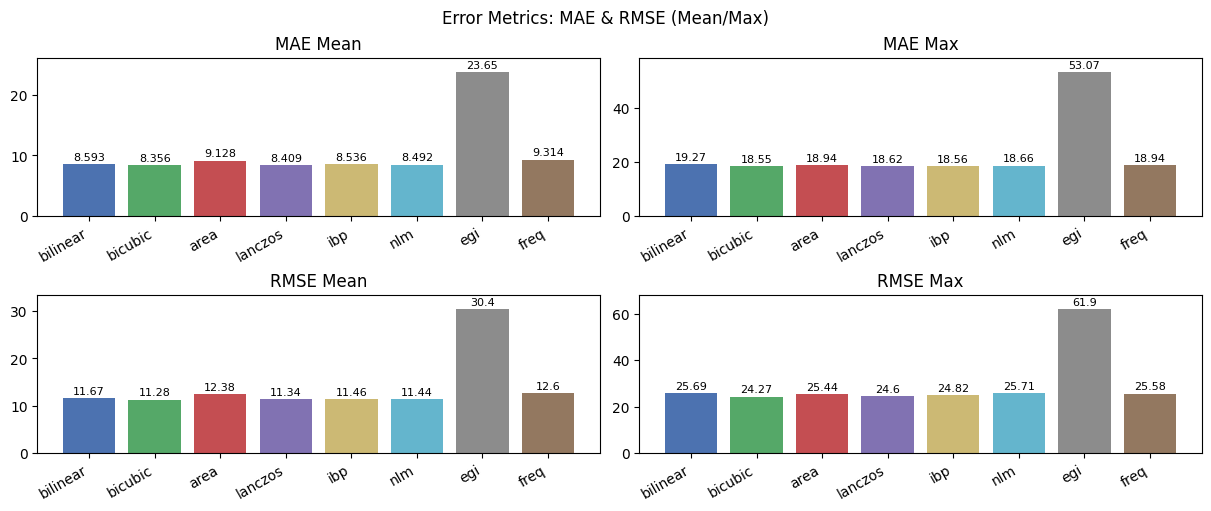

In [6]:
plot_error_metrics_grid(
    metric_summary=metric_summary,
    algorithms=algorithms,
    colors=colors,
    results_dir=CLASSIC_RESULTS_DIR,
    figsize=(12, 5),
)

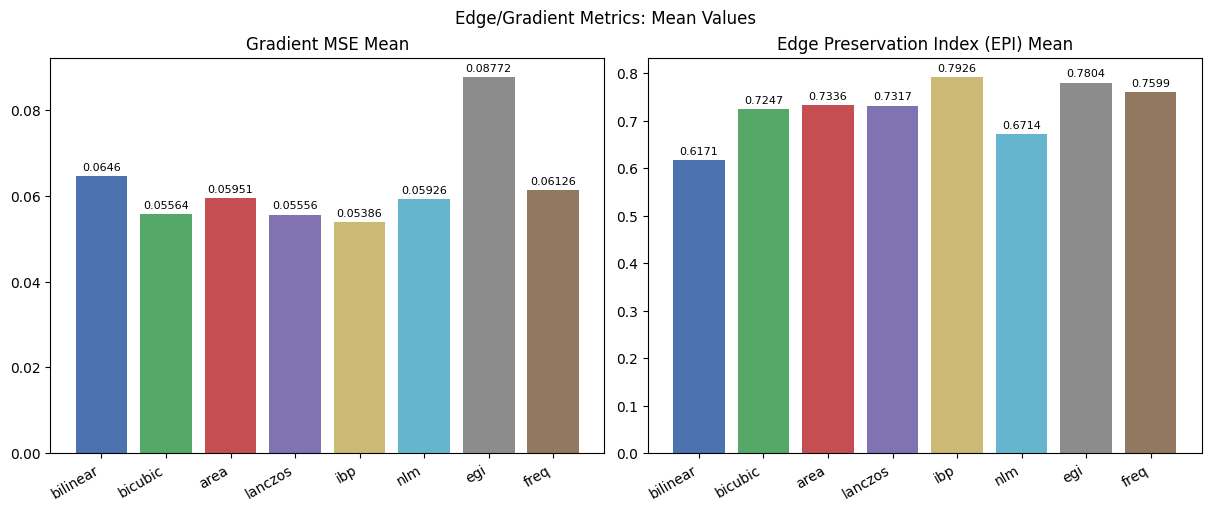

In [7]:
plot_edge_metrics_grid(
    metric_summary=metric_summary,
    algorithms=algorithms,
    colors=colors,
    results_dir=CLASSIC_RESULTS_DIR,
    figsize=(12, 5)
)

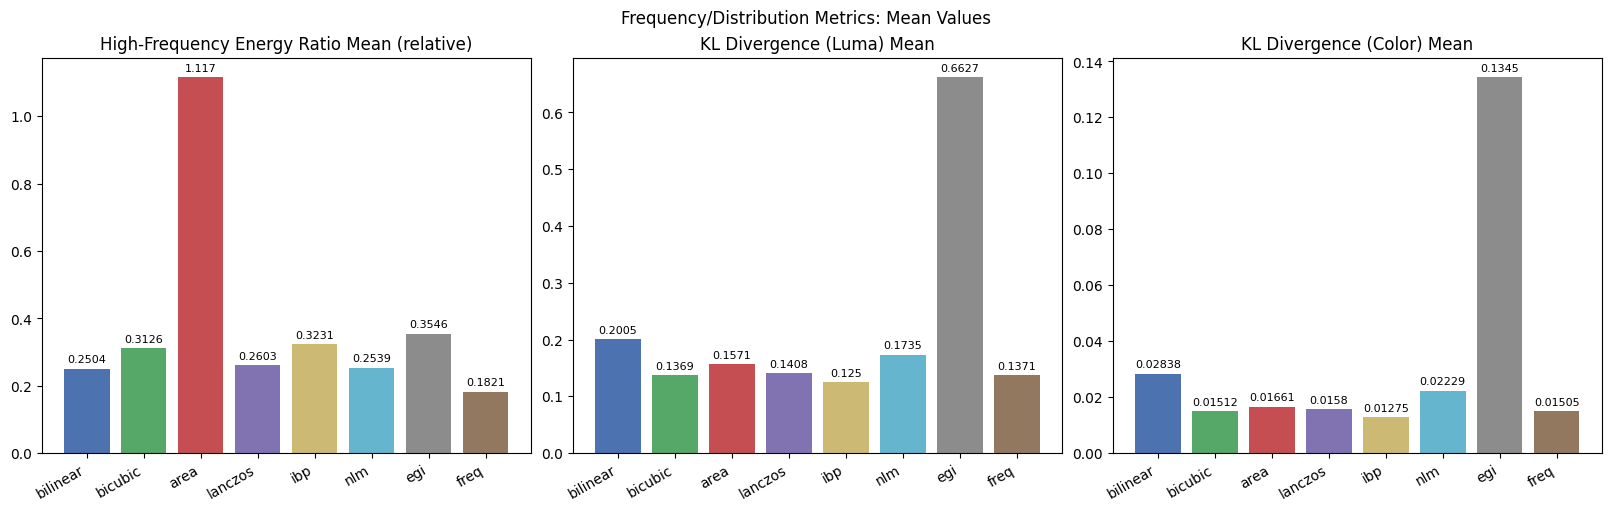

In [8]:
plot_frequency_distribution_metrics_grid(
    metric_summary=metric_summary,
    algorithms=algorithms,
    colors=colors,
    results_dir=CLASSIC_RESULTS_DIR,
    figsize=(16, 5)
)

## Qualitative examples

Outputs of the single image the benchmark keeps aside, chosen with
`example_index`.

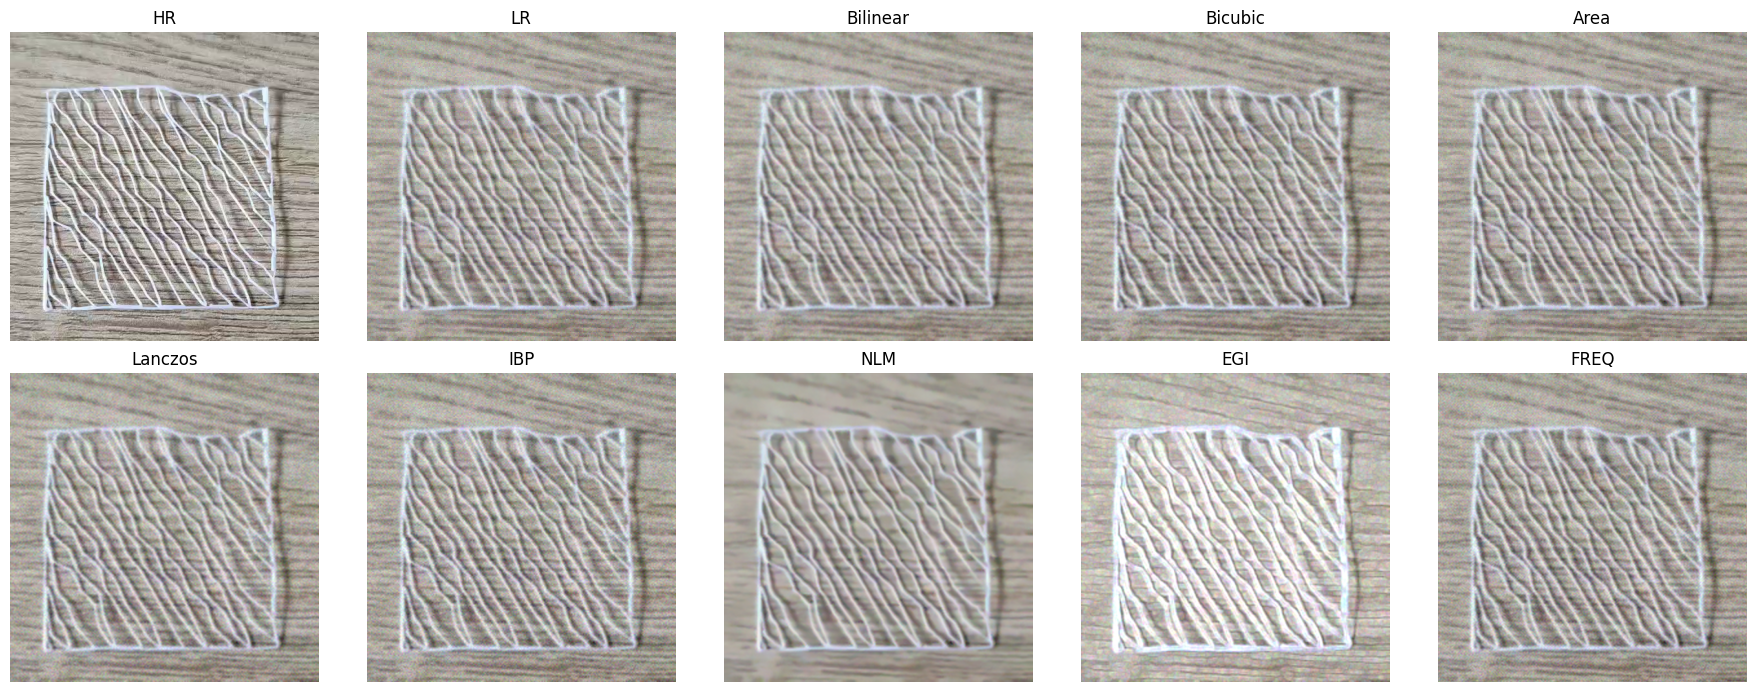

In [9]:
plot_and_save_super_resolution_example(
    results.interpolation_example,
    results.ibp_example,
    results.nlm_example,
    results.egi_example,
    results.freq_example,
    CLASSIC_RESULTS_DIR,
)

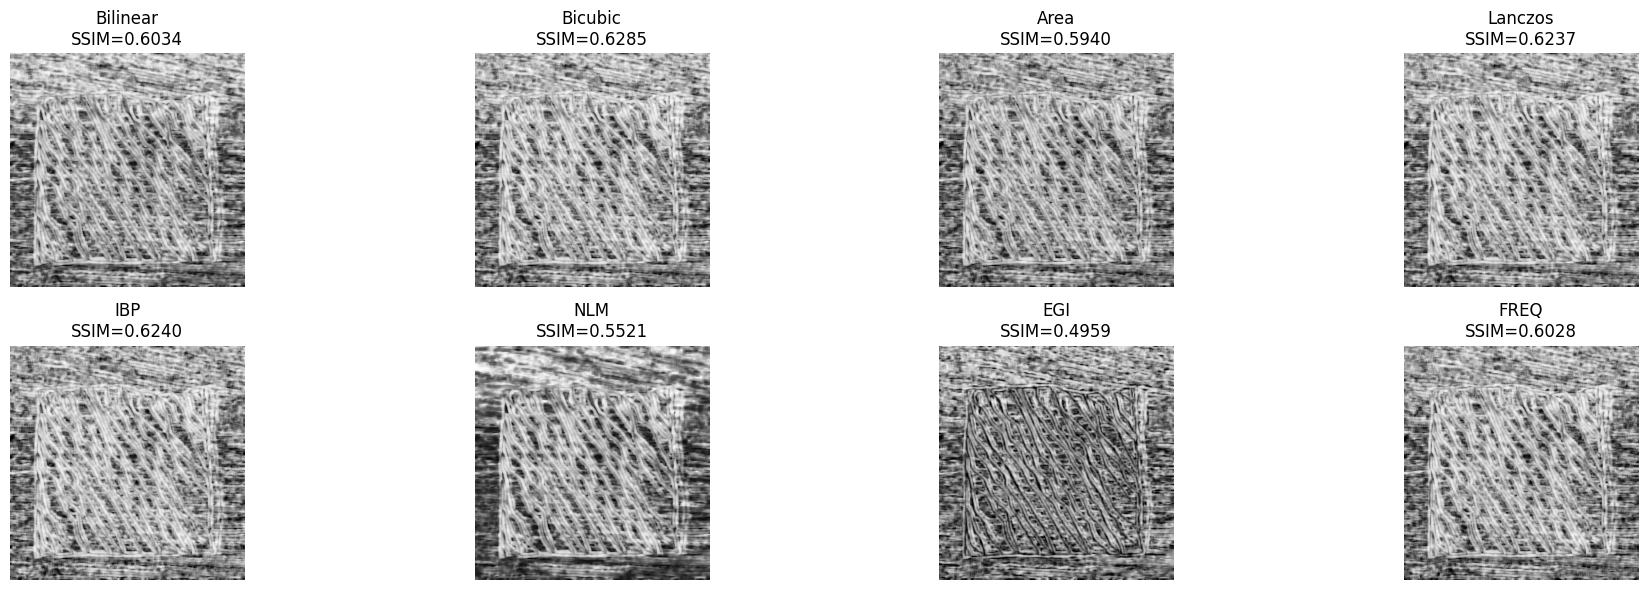

In [10]:
plot_and_save_ssim_similarity_maps(
    results.interpolation_example,
    results.ibp_example,
    results.nlm_example,
    results.egi_example,
    results.freq_example,
    CLASSIC_RESULTS_DIR,
)

## Weighted ranking

Ranking (best to worst):
 1. bicubic     score=0.9739
 2. lanczos     score=0.9704
 3. ibp         score=0.9063
 4. bilinear    score=0.9008
 5. area        score=0.8785
 6. freq        score=0.7978
 7. nlm         score=0.7630
 8. egi         score=0.1407


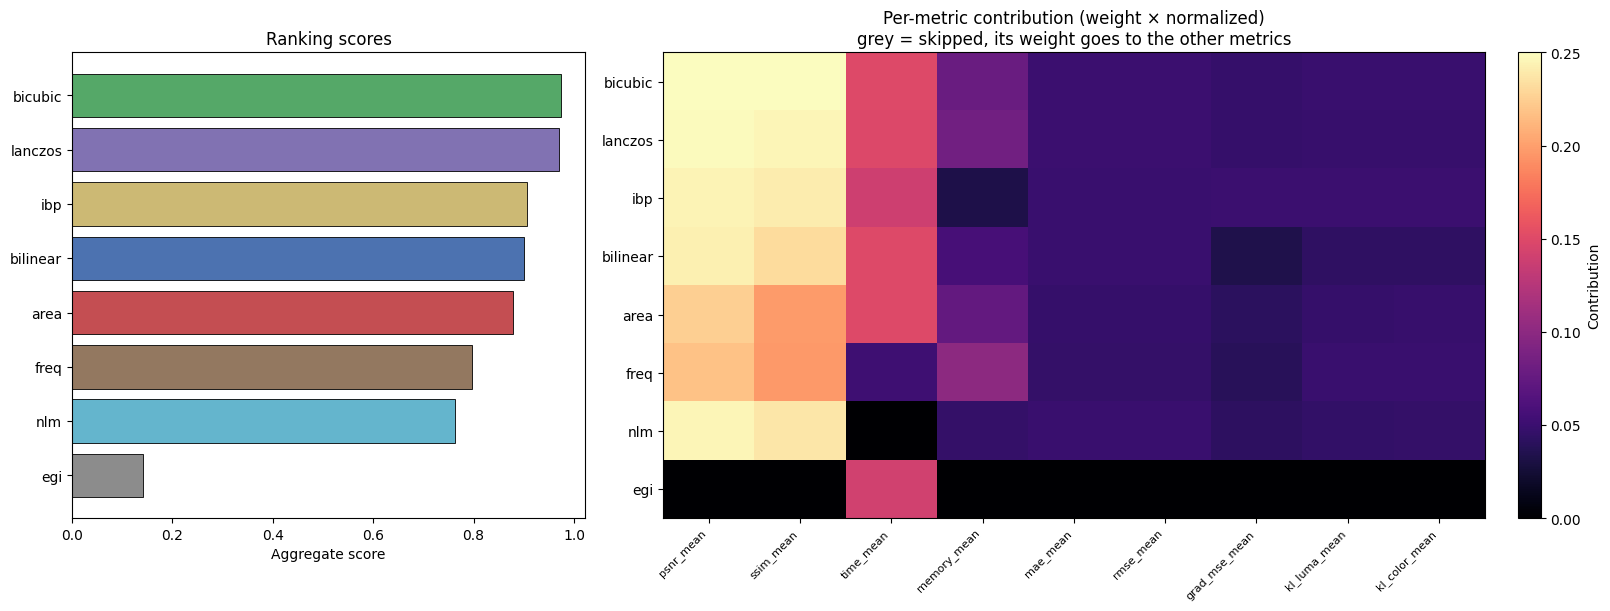

([('bicubic', 0.9738751621489571),
  ('lanczos', 0.9704206136397794),
  ('ibp', 0.9063372773312093),
  ('bilinear', 0.9008233050569225),
  ('area', 0.8785314476504762),
  ('freq', 0.7978258758204634),
  ('nlm', 0.7630166317409147),
  ('egi', 0.140710480264422)],
 {'bilinear': 0.9008233050569225,
  'bicubic': 0.9738751621489571,
  'area': 0.8785314476504762,
  'lanczos': 0.9704206136397794,
  'ibp': 0.9063372773312093,
  'nlm': 0.7630166317409147,
  'egi': 0.140710480264422,
  'freq': 0.7978258758204634},
 {'psnr_mean': (19.192666816348673, 27.92021377889905),
  'ssim_mean': (0.5969152450561523, 0.7524398565292358),
  'time_mean': (0.0001195799998741778, 0.08142904000006738),
  'memory_mean': (260482.84444444443, 1172571.0222222223),
  'mae_mean': (8.356050149215298, 23.646758078427066),
  'rmse_mean': (11.277187540939554, 30.400621881204465),
  'grad_mse_mean': (0.05386398514859544, 0.08771586337987904),
  'kl_luma_mean': (0.12498338746644341, 0.6627049838740768),
  'kl_color_mean': (0

In [11]:
show_algorithm_ranking(
    metric_summary=metric_summary,
    maximize=['psnr_mean', 'ssim_mean'],
    minimize=['time_mean', 'memory_mean', 'mae_mean', 'rmse_mean', 'grad_mse_mean', 'kl_luma_mean', 'kl_color_mean'],
    weights={
        'psnr_mean': 0.25,
        'ssim_mean': 0.25,
        'time_mean': 0.15,
        'memory_mean': 0.10,
        'mae_mean': 0.05,
        'rmse_mean': 0.05,
        'grad_mse_mean': 0.05,
        'kl_luma_mean': 0.05,
        'kl_color_mean': 0.05,
    },
    results_dir=CLASSIC_RESULTS_DIR,
    filename='algorithm_ranking.png',
    dpi=150,
    colors_map=colors
)